# Data Processing for Aalto Shim Dataset (ASD)

-   https://www.sciencedirect.com/science/article/pii/S0888327023006180
-   https://data.mendeley.com/datasets/fsjhhrw2y8/1


In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
from signal_analysis import FFT_TSA, order_track_FFT, order_track_signal, signal_TSA
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import normalize

In [ ]:
# HELPERS


def fix_time(X):
    increment = 1 / 3012  # For 3012 Hz sampling rate
    loc = np.where(X[1:] < X[:-1])[0] + 1  # + 1 needed to get the right index

    if len(loc) == 0:
        return X

    for l in loc:
        print("asd")
        raise
        wrong = X[l - 1] - X[l]
        print(f"Wrong time at {l}")
        diff = np.concatenate([
            np.zeros(l),
            np.ones(len(X) - l) * (increment + wrong),
        ])
        X = X + diff

    return X

## Faults from ASD


In [3]:
# SAMPLE OF DATA

data_folder = Path.cwd().parent.parent.parent / "data" / "mendeley_ASD"
files = data_folder.glob("**/*.csv")

df = pd.read_csv(next(files), sep=",", index_col=0, header=0)
df.head(3)

,time,enc1_ang,enc2_ang,enc3_ang,enc4_ang,enc5_ang,acc1,acc2,acc3,acc4,Torq1,Torq2
0,0.000000,13961988.0,13961988.0,4653996.0,-4653996.0,1163498.9,1.837953,0.695454,1.873710,1.873710,3.973999,0.942261
1,0.000332,13961990.0,13961990.0,4653996.5,-4653996.5,1163499.1,-0.786764,-6.515445,-4.137097,-4.137097,3.989563,0.722656
2,0.000664,13961992.0,13961992.0,4653997.0,-4653997.0,1163499.2,-1.084027,0.072936,-0.497809,-0.497809,3.995972,1.012451


In [ ]:
# PROCESSING

# S - Small (0.01 mm), M - Medium (0.03 mm), L - Large (0.05 mm)
fault_map = [
    ("-", "healthy"),
    ("S", "1-shim"),
    ("S", "2-shim"),
    ("S", "3-shim"),
    ("M", "1-shim"),
    ("M", "2-shim"),
    ("M", "3-shim"),
    ("L", "1-shim"),
    ("L", "2-shim"),
    ("L", "3-shim"),
]

# TSA
revolutions_per_TSA = 45
step_size = 2

# Specify raw data
data_folder = Path.cwd().parent.parent.parent / "data" / "mendeley_ASD"
files = data_folder.glob("**/*.csv")

# Go through files
dfs = []
for f in files:
    # SPECS
    ##

    # Get measurement specifications from file path
    p = f.parts
    print(p)

    rpm = int(p[-2].replace("RPM", ""))
    healthy_GP = 0

    if "Healthy" in p[-1]:
        severity, fault = fault_map[0]
        healthy_GP = 10
    elif "Failure" in p[-1]:
        severity, fault = fault_map[
            int(p[-1].replace(".csv", "").replace("Failure", ""))
        ]
    else:
        raise ValueError(f"Unknown type directory: {p[8]}")

    # SIGNAL
    ##

    # Read CSV
    df = pd.read_csv(f, sep=",", index_col=0, header=0)

    # These sensors not used in this study
    df.drop(
        columns=[
            "enc1_ang",
            "enc2_ang",
            "enc3_ang",
            "enc5_ang",
            # "acc1",
            "Torq1",
            "Torq2",
        ],
        inplace=True,
    )

    # Enc4 runs the wrong way in most files
    if df["enc4_ang"].iloc[0] > df["enc4_ang"].iloc[1]:
        df["enc4_ang"] = -df["enc4_ang"]
        print("Flipped enc4")

    # Sometimes last value is NaN, which causes problems later
    # NOTE: Not a problem in ASD apparently
    # if any([np.isnan(df[s].iloc[-1]) for s in ["acc2", "acc3", "acc4"]]):
    #     df = df.iloc[:-1].reset_index(drop=True)
    #     print("Dropped last row due to NaN")
    #     raise

    # Some measurements have glitches in time
    # NOTE: Not a problem in ASD apparently
    # df["time"] = fix_time(df["time"].to_numpy())

    # Do OT and TSA
    all_sensor_samples_SIGNAL_OT = []
    for sensor in ["acc1", "acc2", "acc3", "acc4"]:
        # SIGNAL OT METHOD
        ###

        # OT
        num_samples_per_revolution = int(3012 / (rpm / 60 / 3)) + 50
        signal_OT = order_track_signal(
            df[sensor].to_numpy(),
            df["time"].to_numpy(),
            df["enc4_ang"].to_numpy(),
            num_samples_per_revolution=num_samples_per_revolution,
        )

        signal_OT_TSA = signal_TSA(
            signal_OT, num_samples_per_revolution, revolutions_per_TSA, step_size
        )
        samples = np.abs(np.fft.rfft(signal_OT_TSA, norm="forward", axis=1))[
            :, : 11 * 15
        ]  # 10 first full GMFs and the DC component

        samples = samples.astype(np.float32)
        all_sensor_samples_SIGNAL_OT.append(samples)

    all_sensor_samples_SIGNAL_OT = np.array(all_sensor_samples_SIGNAL_OT)

    # Make a new row for the DF for every TSA sample
    expanded_rows = []
    for j in range(all_sensor_samples_SIGNAL_OT.shape[1]):
        expanded_rows.append({
            "speed": rpm,
            "severity": severity,
            "healthy_GP": healthy_GP,
            "class": fault,
            "acc1": all_sensor_samples_SIGNAL_OT[0][j],
            "acc2": all_sensor_samples_SIGNAL_OT[1][j],
            "acc3": all_sensor_samples_SIGNAL_OT[2][j],
            "acc4": all_sensor_samples_SIGNAL_OT[3][j],
        })

    # Make DF of one file
    dfs.append(pd.DataFrame(expanded_rows))

# Combine files
dfs = pd.concat(dfs)
dfs.head(3)

('/', 'Users', 'hamalaa14', 'git', 'data', 'mendeley_ASD', '1000RPM', 'Failure1.csv')
Flipped enc4
('/', 'Users', 'hamalaa14', 'git', 'data', 'mendeley_ASD', '1000RPM', 'Failure3.csv')
Flipped enc4
('/', 'Users', 'hamalaa14', 'git', 'data', 'mendeley_ASD', '1000RPM', 'Failure2.csv')
Flipped enc4
('/', 'Users', 'hamalaa14', 'git', 'data', 'mendeley_ASD', '1000RPM', 'Failure6.csv')
('/', 'Users', 'hamalaa14', 'git', 'data', 'mendeley_ASD', '1000RPM', 'Failure7.csv')
('/', 'Users', 'hamalaa14', 'git', 'data', 'mendeley_ASD', '1000RPM', 'Failure5.csv')
('/', 'Users', 'hamalaa14', 'git', 'data', 'mendeley_ASD', '1000RPM', 'Failure4.csv')
('/', 'Users', 'hamalaa14', 'git', 'data', 'mendeley_ASD', '1000RPM', 'Healthy.csv')
('/', 'Users', 'hamalaa14', 'git', 'data', 'mendeley_ASD', '1000RPM', 'Failure9.csv')
('/', 'Users', 'hamalaa14', 'git', 'data', 'mendeley_ASD', '1000RPM', 'Failure8.csv')
('/', 'Users', 'hamalaa14', 'git', 'data', 'mendeley_ASD', '750RPM', 'Failure1.csv')
Flipped enc4
('/'

,speed,severity,healthy_GP,class,acc1,acc2,acc3,acc4
0,1000,S,0,1-shim,"[0.0070211766, 0.009974733, 0.00045425954, 0.0...","[0.00045477063, 0.004112103, 0.006707095, 0.00...","[0.0026763156, 0.010584324, 0.0020057862, 0.00...","[0.0026763156, 0.010584324, 0.0020057862, 0.00..."
1,1000,S,0,1-shim,"[0.0058231363, 0.008862976, 0.0014967987, 0.00...","[0.00036908945, 0.00690458, 0.002160804, 0.005...","[0.00358635, 0.005290399, 0.004973466, 0.00744...","[0.00358635, 0.005290399, 0.004973466, 0.00744..."
2,1000,S,0,1-shim,"[0.004088511, 0.010838345, 0.0030226244, 0.002...","[0.009498415, 0.009787889, 0.0026952869, 0.002...","[4.458289e-05, 0.0073155, 0.0066084014, 0.0043...","[4.458289e-05, 0.0073155, 0.0066084014, 0.0043..."


## Healthy from AGFD


In [5]:
agfd_df = pd.read_feather(Path.cwd().parent.parent / "data" / "AGFD_OT_V2.feather")

In [6]:
agfd_df = agfd_df[
    (agfd_df["OT_method"] == "signal")
    & (agfd_df["class"] == "healthy")
    & (agfd_df["TSA_size"] == 40)
]
agfd_df.drop(columns=["installation", "TSA_size", "OT_method"], inplace=True)
agfd_df["severity"] = "-"
# agfd_df["severity"] = agfd_df["healthy_GP"].astype(str)

agfd_df.dtypes

speed          int64
load           int64
severity      object
healthy_GP     int64
class         object
acc2          object
acc3          object
acc4          object
dtype: object

In [7]:
agfd_df

,speed,load,severity,healthy_GP,class,acc2,acc3,acc4
0,1000,6,-,9,healthy,"[0.15681204, 0.1467509, 0.10267648, 0.18691106...","[0.05340818, 0.0016716623, 0.0476489, 0.021441...","[0.021591298, 0.009342939, 0.0487993, 0.079378..."
1,1000,6,-,9,healthy,"[0.1466057, 0.1743864, 0.13930798, 0.20132023,...","[0.046053, 0.0068802396, 0.032898854, 0.043989...","[0.0075329663, 0.008359205, 0.043041073, 0.069..."
2,1000,6,-,9,healthy,"[0.09177712, 0.18334477, 0.17513958, 0.1564501...","[0.03289293, 0.012730677, 0.01619972, 0.055694...","[0.020638615, 0.013029517, 0.057077166, 0.0670..."
3,1000,6,-,9,healthy,"[0.002870565, 0.18879698, 0.122049056, 0.13415...","[0.039158773, 0.019024143, 0.022401553, 0.0589...","[0.03619223, 0.018786175, 0.05913516, 0.065066..."
4,1000,6,-,9,healthy,"[0.021831641, 0.18802474, 0.057087332, 0.13456...","[0.037059344, 0.0025988477, 0.02698044, 0.0466...","[0.007901126, 0.03898461, 0.0429616, 0.0671614..."
...,...,...,...,...,...,...,...,...
358,1250,1,-,7,healthy,"[0.0061101425, 0.19404344, 0.2532805, 0.154459...","[0.018758697, 0.2074325, 0.40245935, 0.2751332...","[0.043917336, 0.07282743, 0.01662756, 0.159218..."
359,1250,1,-,7,healthy,"[0.013367337, 0.117790505, 0.07280929, 0.12645...","[0.016208734, 0.19829465, 0.3906249, 0.2531644...","[0.055125464, 0.08322324, 0.018300537, 0.17479..."
360,1250,1,-,7,healthy,"[0.048596866, 0.16903041, 0.19394478, 0.042327...","[0.08228853, 0.11919749, 0.32603577, 0.2602158...","[0.05764715, 0.07982433, 0.046778362, 0.151112..."
361,1250,1,-,7,healthy,"[0.02346102, 0.28706518, 0.15339926, 0.1348012...","[0.15673634, 0.088458724, 0.29082465, 0.213228...","[0.05140663, 0.05587122, 0.07505964, 0.1720016..."


In [8]:
# agfd_concattable = agfd_df[agfd_df["severity"].isin(["1", "4", "5", "7"])]
# dfs_combined = pd.concat([dfs.drop(columns=["acc1"], inplace=False), agfd_concattable])

dfs["load"] = -1
dfs_combined = pd.concat([dfs.drop(columns=["acc1"], inplace=False), agfd_df])
dfs_combined

,speed,severity,healthy_GP,class,acc2,acc3,acc4,load
0,1000,S,0,1-shim,"[0.00045477063, 0.004112103, 0.006707095, 0.00...","[0.0026763156, 0.010584324, 0.0020057862, 0.00...","[0.0026763156, 0.010584324, 0.0020057862, 0.00...",-1
1,1000,S,0,1-shim,"[0.00036908945, 0.00690458, 0.002160804, 0.005...","[0.00358635, 0.005290399, 0.004973466, 0.00744...","[0.00358635, 0.005290399, 0.004973466, 0.00744...",-1
2,1000,S,0,1-shim,"[0.009498415, 0.009787889, 0.0026952869, 0.002...","[4.458289e-05, 0.0073155, 0.0066084014, 0.0043...","[4.458289e-05, 0.0073155, 0.0066084014, 0.0043...",-1
3,1000,S,0,1-shim,"[0.007160622, 0.004343717, 0.003140214, 0.0012...","[0.00054326706, 0.008493199, 0.0053683543, 0.0...","[0.00054326706, 0.008493199, 0.0053683543, 0.0...",-1
4,1000,S,0,1-shim,"[0.005431002, 0.0006734777, 0.0064090793, 0.00...","[0.0043384354, 0.004171366, 0.0052435477, 0.00...","[0.0043384354, 0.004171366, 0.0052435477, 0.00...",-1
...,...,...,...,...,...,...,...,...
358,1250,-,7,healthy,"[0.0061101425, 0.19404344, 0.2532805, 0.154459...","[0.018758697, 0.2074325, 0.40245935, 0.2751332...","[0.043917336, 0.07282743, 0.01662756, 0.159218...",1
359,1250,-,7,healthy,"[0.013367337, 0.117790505, 0.07280929, 0.12645...","[0.016208734, 0.19829465, 0.3906249, 0.2531644...","[0.055125464, 0.08322324, 0.018300537, 0.17479...",1
360,1250,-,7,healthy,"[0.048596866, 0.16903041, 0.19394478, 0.042327...","[0.08228853, 0.11919749, 0.32603577, 0.2602158...","[0.05764715, 0.07982433, 0.046778362, 0.151112...",1
361,1250,-,7,healthy,"[0.02346102, 0.28706518, 0.15339926, 0.1348012...","[0.15673634, 0.088458724, 0.29082465, 0.213228...","[0.05140663, 0.05587122, 0.07505964, 0.1720016...",1


In [9]:
# SAVING

# dfs.to_feather(Path.cwd().parent.parent / "data" / "ASD_OT_V1.feather")
dfs_combined.to_feather(Path.cwd().parent.parent / "data" / "ASD_OT_COMB_V1.feather")

In [10]:
dfs_combined[
    (dfs_combined["class"] == "healthy")
    # (dfs_combined["class"] == "1-shim")
    & (dfs_combined["speed"] == 1250)
    & (dfs_combined["load"] == -1)
    # & (dfs_combined["severity"] == "S")
]

,speed,severity,healthy_GP,class,acc2,acc3,acc4,load
0,1250,-,10,healthy,"[0.003285584, 0.0029928202, 0.00062988803, 0.0...","[0.002068911, 0.0010116869, 0.0009221071, 0.00...","[0.002068911, 0.0010116869, 0.0009221071, 0.00...",-1
1,1250,-,10,healthy,"[0.003190508, 0.0029717528, 0.0006891638, 0.00...","[0.0020725506, 0.0010197172, 0.00091058516, 0....","[0.0020725506, 0.0010197172, 0.00091058516, 0....",-1
2,1250,-,10,healthy,"[0.0033578072, 0.0029372163, 0.00067385635, 0....","[0.0021283864, 0.0010260158, 0.00086141925, 0....","[0.0021283864, 0.0010260158, 0.00086141925, 0....",-1
3,1250,-,10,healthy,"[0.0036031185, 0.0028184352, 0.0008559674, 0.0...","[0.0020671168, 0.0010288907, 0.00092088734, 0....","[0.0020671168, 0.0010288907, 0.00092088734, 0....",-1
4,1250,-,10,healthy,"[0.003051747, 0.0028849873, 0.00027453917, 0.0...","[0.002149124, 0.0011063826, 0.00088299083, 0.0...","[0.002149124, 0.0011063826, 0.00088299083, 0.0...",-1
...,...,...,...,...,...,...,...,...
494,1250,-,10,healthy,"[0.003386056, 0.003165365, 0.0017618936, 0.005...","[0.0018542021, 0.0012461866, 0.00092355354, 0....","[0.0018542021, 0.0012461866, 0.00092355354, 0....",-1
495,1250,-,10,healthy,"[0.0034857425, 0.0039925203, 0.0018466142, 0.0...","[0.0017266191, 0.00089285173, 0.0010276017, 0....","[0.0017266191, 0.00089285173, 0.0010276017, 0....",-1
496,1250,-,10,healthy,"[0.0039246324, 0.0037555865, 0.0015325695, 0.0...","[0.0018784872, 0.0009769351, 0.0013518701, 0.0...","[0.0018784872, 0.0009769351, 0.0013518701, 0.0...",-1
497,1250,-,10,healthy,"[0.004085809, 0.0032970572, 0.001083401, 0.006...","[0.0020249041, 0.0012751437, 0.0012867141, 0.0...","[0.0020249041, 0.0012751437, 0.0012867141, 0.0...",-1


## Plotting stuff


In [257]:
agfd_df = pd.read_feather(Path.cwd().parent.parent / "data" / "AGFD_OT_V2.feather")
agfd_df = agfd_df[(agfd_df["OT_method"] == "signal")]

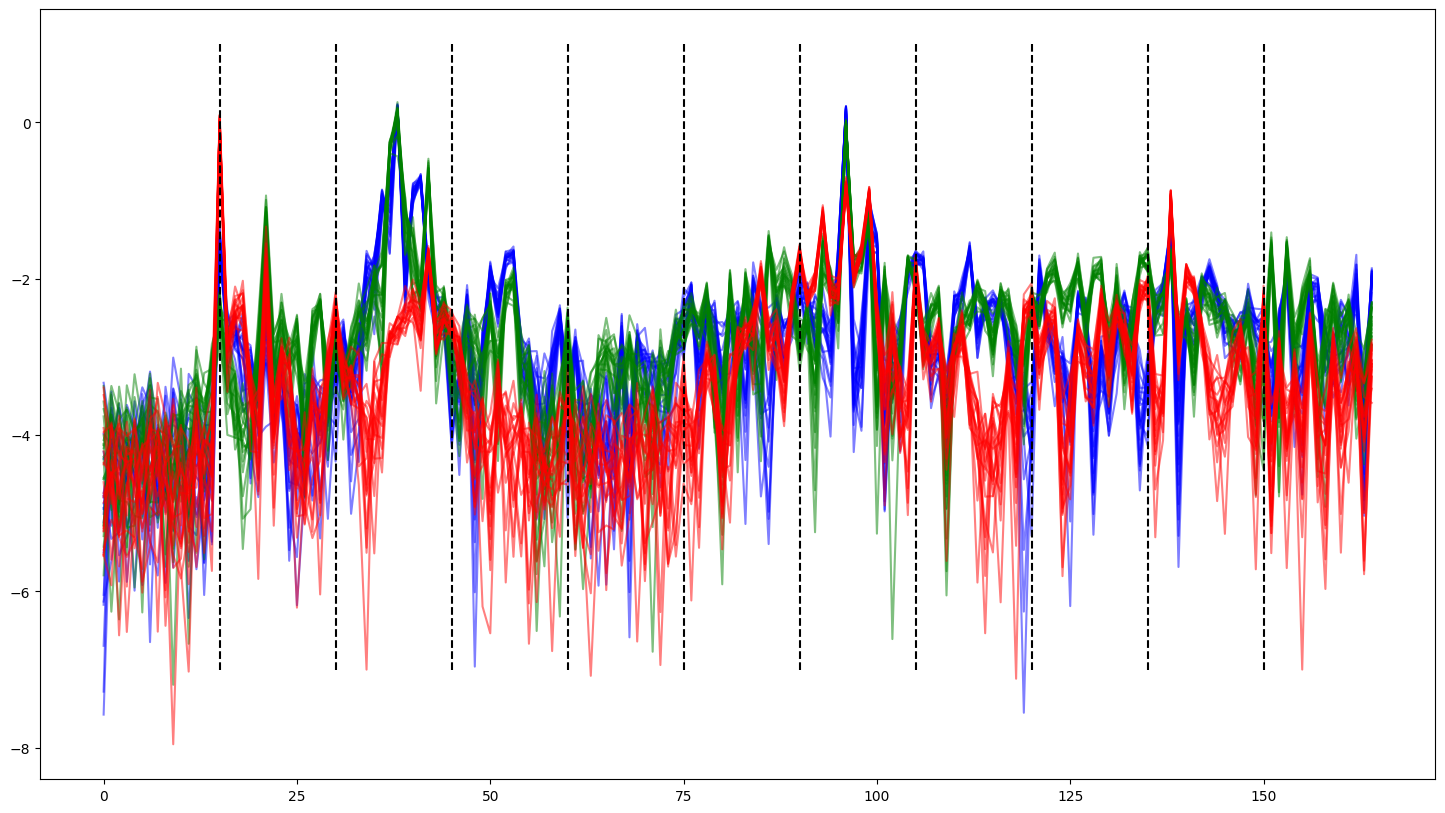

In [272]:
speed = 750
load = 1
installation = 1

# agfd_filt = agfd_df[
#     (agfd_df["speed"] == 1250) & (agfd_df["load"] == load) & (agfd_df["severity"] == "L") & (agfd_df["installation"] == installation)
# ]
# agfd_filt_2 = agfd_df[
#     (agfd_df["speed"] == speed) & (agfd_df["load"] == load) & (agfd_df["severity"] == "L") & (agfd_df["installation"] == installation)
# ]

agfd_filt = agfd_df[
    (agfd_df["speed"] == speed)
    & (agfd_df["load"] == load)
    & (agfd_df["severity"] == "S")
    & (agfd_df["class"] == "crack")
    & (agfd_df["installation"] == installation)
]
agfd_filt_2 = agfd_df[
    (agfd_df["speed"] == speed)
    & (agfd_df["load"] == load)
    & (agfd_df["severity"] == "S")
    & (agfd_df["class"] == "crack")
    & (agfd_df["installation"] == 2)
]
agfd_filt_3 = agfd_df[
    (agfd_df["speed"] == speed)
    & (agfd_df["load"] == load)
    & (agfd_df["severity"] == "L")
    & (agfd_df["class"] == "wear")
    & (agfd_df["installation"] == installation)
]


f = plt.figure(figsize=(18, 10))
for row in agfd_filt["acc3"][::25]:
    plt.plot(np.log(row), color="blue", alpha=0.5)

for row in agfd_filt_2["acc3"][::25]:
    plt.plot(np.log(row), color="green", alpha=0.5)

for row in agfd_filt_3["acc3"][::25]:
    plt.plot(np.log(row), color="red", alpha=0.5)

# asd_filt = dfs[(dfs["class"] == "healthy") & (dfs["speed"] == speed)]
# for row in asd_filt["acc3"][::25]:
#     plt.plot(np.log(row), color="orange")

plt.vlines(
    x=[i * 15 for i in range(1, 11)],
    ymin=-7,
    ymax=1,
    colors="black",
    linestyles="dashed",
)

plt.show()

In [246]:
unsw_df = pd.read_feather(
    Path.cwd().parent.parent / "data" / "UNSW_gear_crack_OT_V2.feather"
)
unsw_df = unsw_df[(unsw_df["OT_method"] == "signal")]
unsw_df

,speed,load,severity,OT_method,TSA_size,signal
32,5,20,S,signal,40,"[0.009778606, 0.000587674, 0.00089263084, 0.00..."
33,5,20,S,signal,40,"[0.0099903485, 0.0006395894, 0.00066690944, 0...."
34,5,20,S,signal,40,"[0.010139683, 0.0006328963, 0.00075291045, 0.0..."
35,5,20,S,signal,40,"[0.010238826, 0.00085355365, 0.00087258115, 0...."
36,5,20,S,signal,40,"[0.0105761625, 0.00077370583, 0.001046263, 0.0..."
...,...,...,...,...,...,...
31375,10,20,H,signal,40,"[0.00425586, 0.0012884028, 0.0025681409, 0.000..."
31376,10,20,H,signal,40,"[0.0039629852, 0.0012567939, 0.002315813, 0.00..."
31377,10,20,H,signal,40,"[0.004325461, 0.0011508899, 0.0019245192, 0.00..."
31378,10,20,H,signal,40,"[0.004082624, 0.0011446156, 0.0025835421, 0.00..."


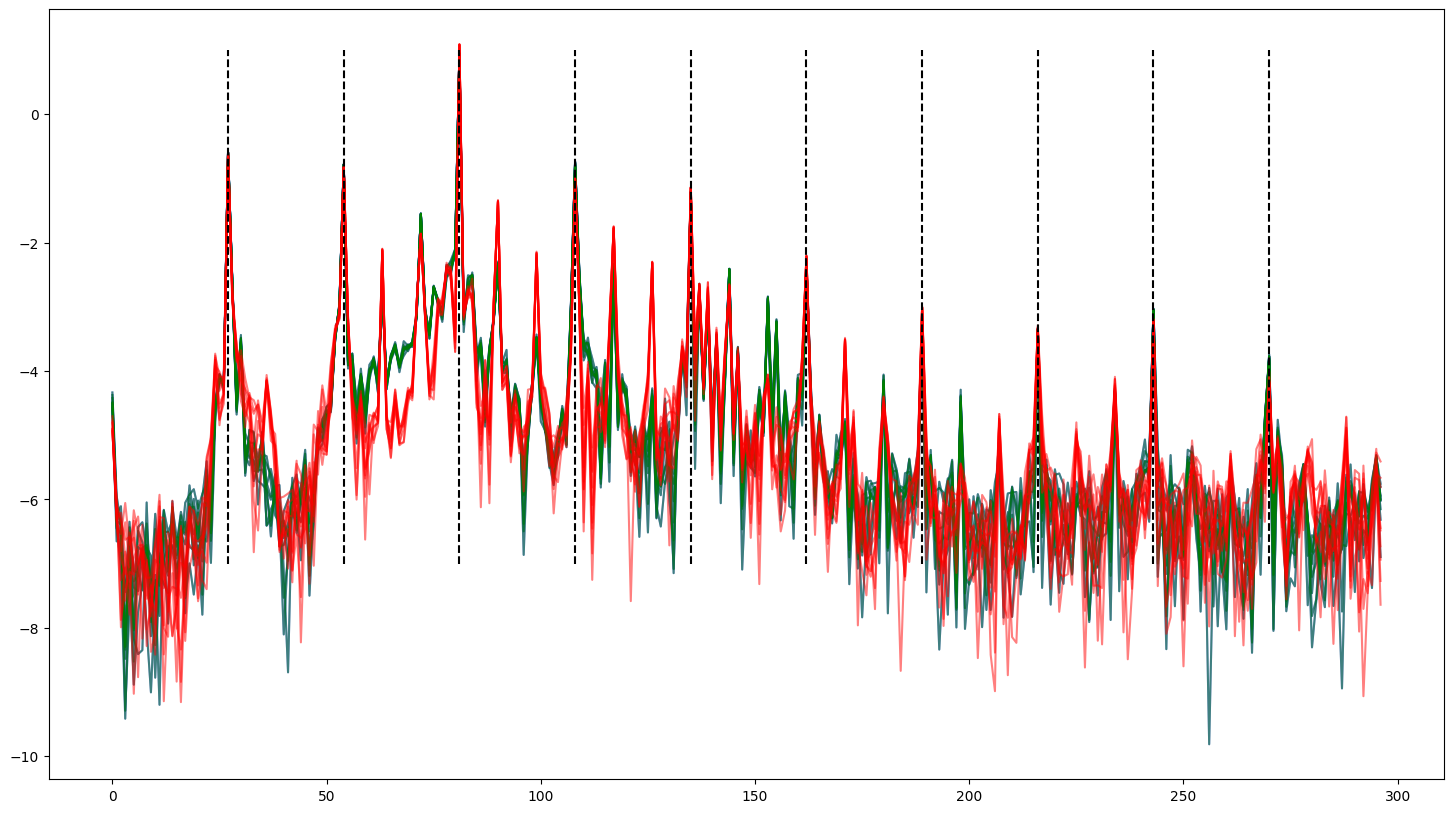

In [251]:
speed = 10
load = 20

unsw_filt = unsw_df[
    (unsw_df["speed"] == speed)
    & (unsw_df["load"] == load)
    & (unsw_df["severity"] == "L")
]
unsw_filt_2 = unsw_df[
    (unsw_df["speed"] == speed)
    & (unsw_df["load"] == load)
    & (unsw_df["severity"] == "L")
]
unsw_filt_3 = unsw_df[
    (unsw_df["speed"] == speed)
    & (unsw_df["load"] == load)
    & (unsw_df["severity"] == "S")
]


f = plt.figure(figsize=(18, 10))
# for row in unsw_filt["acc4"][:25]:
for row in unsw_filt["signal"][::10]:
    plt.plot(np.log(row), color="blue", alpha=0.5)

for row in unsw_filt_2["signal"][::10]:
    plt.plot(np.log(row), color="green", alpha=0.5)

for row in unsw_filt_3["signal"][::10]:
    plt.plot(np.log(row), color="red", alpha=0.5)

# asd_filt = dfs[(dfs["class"] == "healthy") & (dfs["speed"] == speed)]
# for row in asd_filt["acc3"][::25]:
#     plt.plot(np.log(row), color="orange")

plt.vlines(
    x=[i * 27 for i in range(1, 11)],
    ymin=-7,
    ymax=1,
    colors="black",
    linestyles="dashed",
)

plt.show()

In [274]:
mcc5_df = pd.read_feather(Path.cwd().parent.parent / "data" / "MCC5-THU_OT_V2.feather")
mcc5_df = mcc5_df[(mcc5_df["OT_method"] == "signal")]
mcc5_df

,speed,load,severity,class,circulation,OT_method,TSA_size,motor_vibration_x,motor_vibration_y,motor_vibration_z,gearbox_vibration_x,gearbox_vibration_y,gearbox_vibration_z
14,1000,10,M,broken_tooth,speed,signal,30,"[0.00972744, 6.167556e-05, 6.5828215e-05, 0.00...","[0.00514484, 0.00034701452, 6.709307e-05, 0.00...","[0.0044768187, 3.1205367e-05, 0.00013953702, 0...","[0.0007683673, 0.00030872086, 0.00015979752, 0...","[0.00768809, 0.00031490822, 0.00019065457, 0.0...","[0.007682852, 0.00016354253, 8.730352e-05, 0.0..."
15,1000,10,M,broken_tooth,speed,signal,30,"[0.009765815, 0.00010694492, 3.722281e-05, 0.0...","[0.0051138755, 0.0003547434, 8.25982e-05, 0.00...","[0.00441038, 3.9784092e-05, 0.00022096053, 0.0...","[0.0008022104, 0.0003242424, 0.000105653955, 0...","[0.00762301, 0.00034772896, 0.00019466251, 0.0...","[0.0077097253, 0.00016328781, 6.6242916e-05, 0..."
16,1000,10,M,broken_tooth,speed,signal,30,"[0.009738309, 7.423542e-05, 3.854512e-05, 0.00...","[0.005135728, 0.00036547013, 7.384935e-05, 8.6...","[0.0044192895, 2.5435427e-05, 0.00020090918, 0...","[0.0008069796, 0.0003066716, 0.0001597969, 0.0...","[0.0076123527, 0.00036282963, 0.00017346271, 0...","[0.007717151, 0.00014758292, 5.5816763e-05, 0...."
17,1000,10,M,broken_tooth,speed,signal,30,"[0.00975731, 8.783297e-05, 5.8433478e-05, 0.00...","[0.0051652, 0.00037532632, 9.418235e-05, 0.000...","[0.004465479, 2.2038728e-05, 0.00016754196, 0....","[0.00097414263, 0.00031225925, 0.00011888716, ...","[0.007560931, 0.00039827736, 0.00014525579, 0....","[0.0077952505, 0.00014579605, 5.0656716e-05, 0..."
18,1000,10,M,broken_tooth,speed,signal,30,"[0.009737878, 7.732335e-05, 6.1024788e-05, 0.0...","[0.005175596, 0.0003730308, 7.345655e-05, 6.24...","[0.0044687, 3.2903856e-05, 0.00012769218, 0.00...","[0.00088992633, 0.00024619975, 0.000115235154,...","[0.007662049, 0.00030321509, 8.807339e-05, 0.0...","[0.007682748, 0.00013651272, 5.7054815e-05, 0...."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
21,1000,20,XL,crack,speed,signal,30,"[0.010567245, 0.00016777047, 4.352655e-05, 0.0...","[0.0040224805, 0.00033610838, 1.3311641e-05, 8...","[0.003632312, 0.00024023282, 9.622605e-05, 0.0...","[0.0012759735, 0.00018235545, 7.2124174e-05, 0...","[0.007264817, 0.0005534068, 0.0001899925, 0.00...","[0.007970861, 3.9503953e-05, 0.00010691966, 0...."
22,1000,20,XL,crack,speed,signal,30,"[0.010334768, 0.00018876279, 6.240209e-05, 0.0...","[0.004373625, 0.0003587396, 4.9956852e-05, 7.1...","[0.0035151178, 0.00021430856, 6.059854e-05, 0....","[0.0013120874, 0.00024381155, 3.0151985e-05, 0...","[0.0073052724, 0.00062476035, 0.00011376596, 0...","[0.008048304, 0.00013635404, 4.9101494e-05, 0...."
23,1000,20,XL,crack,speed,signal,30,"[0.010118486, 0.00013959598, 2.2868464e-05, 0....","[0.004570057, 0.00036682517, 4.4007036e-05, 4....","[0.004687052, 0.00034842192, 0.00020087457, 0....","[0.0013360975, 0.00028761203, 0.00023307155, 0...","[0.0072826943, 0.00066473143, 0.00024595723, 0...","[0.008067805, 0.00013872139, 0.0001921718, 0.0..."
24,1000,20,XL,crack,speed,signal,30,"[0.010066709, 0.00022032781, 6.981259e-05, 6.2...","[0.0046623955, 0.00036142307, 4.3537435e-05, 6...","[0.00443569, 0.00048261997, 8.904939e-05, 0.00...","[0.0013799663, 0.0003191798, 0.0002493036, 0.0...","[0.007268781, 0.00064792135, 0.00023789177, 0....","[0.008067712, 0.00019439608, 0.00017018292, 0...."


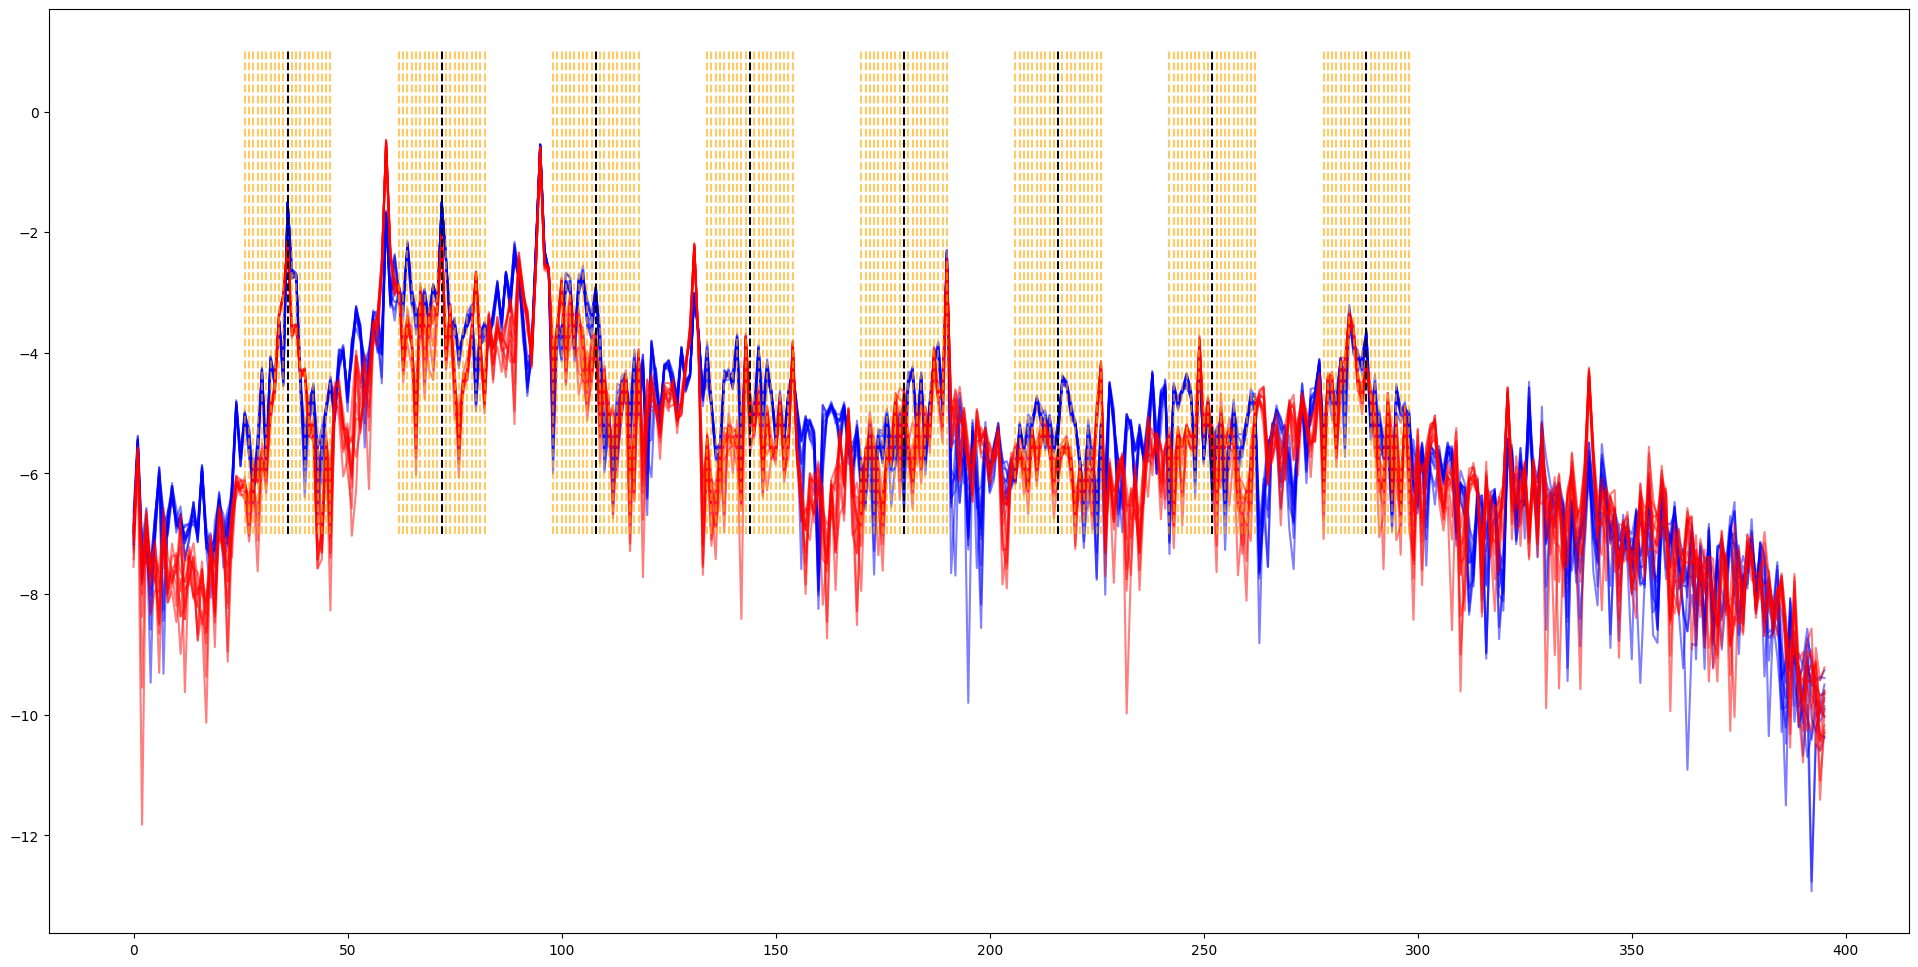

In [366]:
speed = 3000
load = 10
circulation = "speed"
# sensor = "motor_vibration_z"
sensor = "gearbox_vibration_x"

mcc5_filt = mcc5_df[
    (mcc5_df["speed"] == speed)
    & (mcc5_df["load"] == load)
    & (mcc5_df["circulation"] == circulation)
    & (mcc5_df["class"] == "wear")
    & (mcc5_df["severity"] == "L")
]
mcc5_filt_2 = mcc5_df[
    (mcc5_df["speed"] == speed)
    & (mcc5_df["load"] == load)
    & (mcc5_df["circulation"] == circulation)
    & (mcc5_df["class"] == "wear")
    & (mcc5_df["severity"] == "M")
]
mcc5_filt_3 = mcc5_df[
    (mcc5_df["speed"] == speed)
    & (mcc5_df["load"] == load)
    & (mcc5_df["circulation"] == "torque")
    & (mcc5_df["class"] == "healthy")
    # & (mcc5_df["severity"] == "S")
]


f = plt.figure(figsize=(24, 12))
for row in mcc5_filt[sensor][:10:]:
    # for row in mcc5_filt[sensor][::10]:
    plt.plot(np.log(row), color="blue", alpha=0.5)

# for row in mcc5_filt_2[sensor][::10]:
#     plt.plot(np.log(row), color="green", alpha=0.5)

for row in mcc5_filt_3[sensor][:10:]:
    plt.plot(np.log(row), color="red", alpha=0.5)

offsets = [0, -10, -9, -8, -7, -6, -5, -4, -3, -2, -1, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
# offsets = [0, -17, -16, -15, -14, -13, -4, -3, -2, -1, 1, 2, 3, 4, 13, 14, 15, 16, 17]
colors = ["black"] + ["orange"] * len(offsets)
alphas = [1.0] + [0.6] * len(offsets)

for offset, color, alpha in zip(offsets, colors, alphas):
    linestyle = "dashed" if offset == 0 else "dashed"
    plt.vlines(
        x=[i * 36 + offset for i in range(1, 9)],
        ymin=-7,
        ymax=1,
        colors=color,
        linestyles=linestyle,
        alpha=alpha,
    )

plt.show()

## Error checking


In [66]:
df_test = pd.read_feather(Path.cwd().parent.parent / "data" / "AGFD_OT.feather")
df_test[
    (df_test["class"] == "pitting")
    & (df_test["speed"] == 750)
    & (df_test["load"] == 1)
    & (df_test["installation"] == 3)
    & (df_test["OT_method"] == "signal")
]

SyntaxError: invalid syntax (1326619838.py, line 4)

In [7]:
# Change the class of all entries where class is "crack" and severity is "L" to "missing_tooth"
df_test.loc[(df_test["class"] == "crack") & (df_test["severity"] == "L"), "class"] = (
    "missing_tooth"
)

In [8]:
df_test["class"].value_counts()

class
wear             74011
pitting          73948
healthy          47381
crack            37223
missing_tooth    37022
Name: count, dtype: int64

In [9]:
df_test[df_test["class"] == "missing_tooth"]

,speed,load,installation,severity,healthy_GP,class,OT_method,TSA_size,sample_index,acc2,acc3,acc4
0,1000,6,1,L,0,missing_tooth,signal,40,0,"[0.020037346, 0.0767442, 0.16351262, 0.0607441...","[0.009573726, 0.02936791, 0.017492468, 0.02187...","[0.06668435, 0.02938217, 0.03508344, 0.0621913..."
1,1000,6,1,L,0,missing_tooth,signal,40,0,"[0.015160634, 0.062139254, 0.109139025, 0.0959...","[0.028065741, 0.021950966, 0.012860192, 0.0457...","[0.025471525, 0.0632136, 0.009882987, 0.018768..."
2,1000,6,1,L,0,missing_tooth,signal,40,0,"[0.0359732, 0.16623895, 0.14077553, 0.18733773...","[0.02220725, 0.08092397, 0.058103908, 0.021060...","[0.020739503, 0.00983523, 0.037948664, 0.04550..."
3,1000,6,1,L,0,missing_tooth,signal,40,0,"[0.012654571, 0.075867735, 0.07790708, 0.03368...","[0.013824502, 0.05642796, 0.03622521, 0.026731...","[0.11304247, 0.061201032, 0.092183836, 0.11114..."
4,1000,6,1,L,0,missing_tooth,signal,40,0,"[0.05746909, 0.14306132, 0.13148698, 0.0509645...","[0.07792025, 0.105303936, 0.104539074, 0.08134...","[0.14345147, 0.0658718, 0.11429467, 0.1362959,..."
...,...,...,...,...,...,...,...,...,...,...,...,...
939,1250,1,3,L,0,missing_tooth,fft,40,0,"[0.036322765, 0.0074643274, 0.028509518, 0.000...","[1.9200257, 1.9752719, 1.8148035, 2.0742407, 1...","[0.15840793, 0.32054853, 0.34337947, 0.4721284..."
940,1250,1,3,L,0,missing_tooth,fft,40,0,"[0.034552258, 0.0067188125, 0.027208747, 0.001...","[2.2611518, 2.0966542, 1.922385, 2.098742, 1.8...","[0.24758644, 0.34626567, 0.40842694, 0.4741158..."
941,1250,1,3,L,0,missing_tooth,fft,40,0,"[0.033286337, 0.005906829, 0.028284796, 0.0016...","[2.2243018, 2.1461978, 1.9647936, 2.1016436, 1...","[0.40073085, 0.5154666, 0.50626487, 0.6036616,..."
942,1250,1,3,L,0,missing_tooth,fft,40,0,"[0.03526114, 0.0064794146, 0.029427346, 0.0019...","[2.0869362, 1.9721978, 1.7835532, 1.8640234, 1...","[0.45676956, 0.5968722, 0.5633561, 0.6055579, ..."


In [10]:
df_test = pd.read_csv(
    Path.cwd().parent.parent.parent
    / "data"
    / "mendeley_AGFD3kHz"
    / "1500RPM"
    / "0_12Nm"
    / "Faulty"
    / "Inst_1"
    / "Mild_Pitting_GP1.csv",
    sep=",",
    index_col=0,
    header=0,
)
t = df_test["time"].to_numpy()  # [-100000:]
# angle = -df_test["enc4_ang"].to_numpy()  # [-100000:]
signal = df_test["acc4"].to_numpy()  # [-100000:]

In [11]:
np.sum(np.isnan(signal))

np.int64(1)

In [12]:
t[-3:]

array([163.8191 , 163.81943, 163.81976])

## Time skipping showcase


In [13]:
df = pd.read_csv(
    Path.cwd().parent.parent.parent
    / "data"
    / "mendeley_AGFD3kHz"
    / "1500RPM"
    / "0_12Nm"
    / "Healthy"
    / "GP1.csv",
    sep=",",
    index_col=0,
    header=0,
)
t = df["time"].to_numpy()  # [-100000:]
angle = -df["enc4_ang"].to_numpy()  # [-100000:]
# signal = df["acc2"].to_numpy()  # [-100000:]

In [14]:
crossings = np.where(np.logical_and(angle[:-1] % 360 <= 5, angle[1:] % 360 > 5))[0]
px.line(np.diff(crossings[int(len(crossings) * 0.7) : int(len(crossings) * 0.9)]))

In [15]:
px.line(np.diff(t[int(len(t) * 0.7) : int(len(t) * 0.9)]))

## Visualization


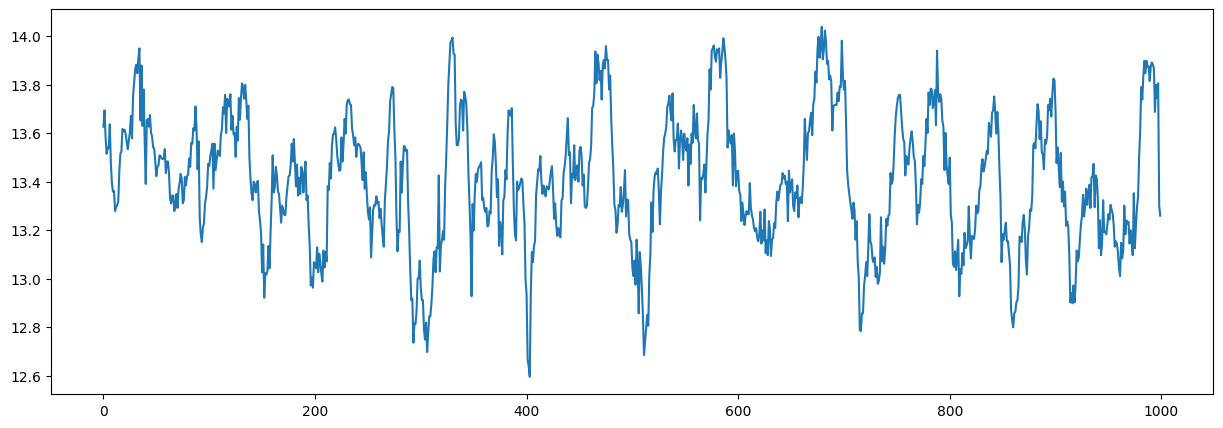

In [16]:
df = pd.read_csv(
    Path.cwd().parent.parent.parent
    / "data"
    / "mendeley_AGFD3kHz"
    / "500RPM"
    / "1_31Nm"
    / "Healthy"
    / "GP9.csv",
    sep=",",
    index_col=0,
    header=0,
)
t = df["time"].to_numpy()
angle = -df["enc4_ang"].to_numpy()
signal = df["Torq1"].to_numpy()

plt.figure(figsize=(15, 5))
plt.plot(signal[-1000:])

np.float64(1.503796886386719)

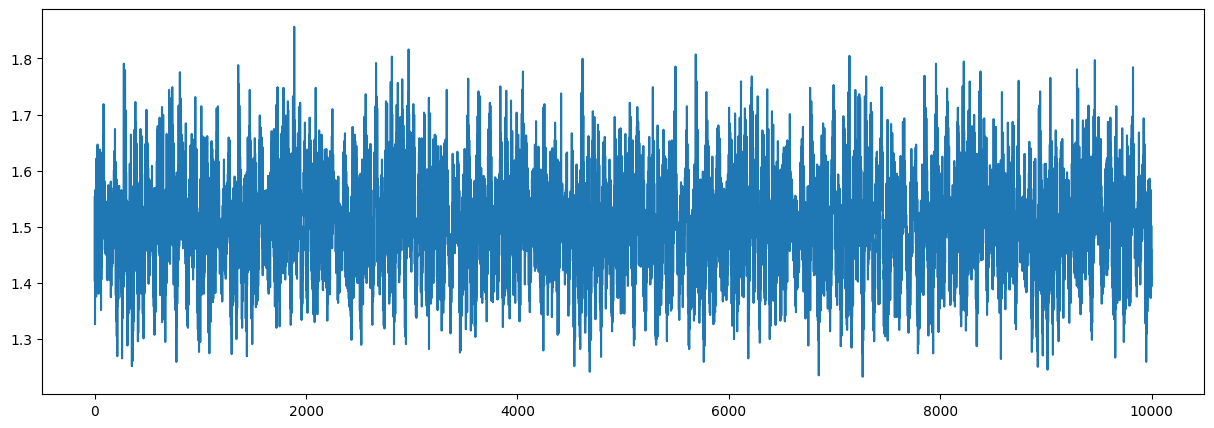

In [17]:
df = pd.read_csv(
    Path.cwd().parent.parent.parent
    / "data"
    / "mendeley_AGFD3kHz"
    / "500RPM"
    / "1_31Nm"
    / "Faulty"
    / "Inst_2"
    / "Mild_TFF_GP9.csv",
    sep=",",
    index_col=0,
    header=0,
)
t = df["time"].to_numpy()
angle = -df["enc4_ang"].to_numpy()
signal = df["Torq2"].to_numpy()

plt.figure(figsize=(15, 5))
plt.plot(signal[-10000:])

signal.mean()

## Clustering Visualizations


In [26]:
# Crack
A1 = np.stack(
    df_test[
        (df_test["speed"] == 1000)
        & (df_test["class"] == "crack")
        & (df_test["load"] == 6)
        & (df_test["severity"] == "S")
        & (df_test["installation"] == 1)
    ]["acc3"]
)
A2 = np.stack(
    df_test[
        (df_test["speed"] == 1000)
        & (df_test["class"] == "crack")
        & (df_test["load"] == 11)
        & (df_test["severity"] == "S")
        & (df_test["installation"] == 1)
    ]["acc3"]
)
A3 = np.stack(
    df_test[
        (df_test["speed"] == 500)
        & (df_test["class"] == "crack")
        & (df_test["load"] == 6)
        & (df_test["severity"] == "S")
        & (df_test["installation"] == 1)
    ]["acc3"]
)
A4 = np.stack(
    df_test[
        (df_test["speed"] == 1000)
        & (df_test["class"] == "crack")
        & (df_test["load"] == 6)
        & (df_test["severity"] == "L")
        & (df_test["installation"] == 1)
    ]["acc3"]
)
A5 = np.stack(
    df_test[
        (df_test["speed"] == 1000)
        & (df_test["class"] == "crack")
        & (df_test["load"] == 6)
        & (df_test["severity"] == "S")
        & (df_test["installation"] == 2)
    ]["acc3"]
)

# Wear
B1 = np.stack(
    df_test[
        (df_test["speed"] == 1000)
        & (df_test["class"] == "wear")
        & (df_test["load"] == 6)
        & (df_test["severity"] == "L")
        & (df_test["installation"] == 1)
    ]["acc3"]
)
B2 = np.stack(
    df_test[
        (df_test["speed"] == 1000)
        & (df_test["class"] == "wear")
        & (df_test["load"] == 11)
        & (df_test["severity"] == "L")
        & (df_test["installation"] == 1)
    ]["acc3"]
)
B3 = np.stack(
    df_test[
        (df_test["speed"] == 500)
        & (df_test["class"] == "wear")
        & (df_test["load"] == 6)
        & (df_test["severity"] == "L")
        & (df_test["installation"] == 1)
    ]["acc3"]
)
B4 = np.stack(
    df_test[
        (df_test["speed"] == 1000)
        & (df_test["class"] == "wear")
        & (df_test["load"] == 6)
        & (df_test["severity"] == "S")
        & (df_test["installation"] == 1)
    ]["acc3"]
)
B5 = np.stack(
    df_test[
        (df_test["speed"] == 1000)
        & (df_test["class"] == "wear")
        & (df_test["load"] == 6)
        & (df_test["severity"] == "L")
        & (df_test["installation"] == 2)
    ]["acc3"]
)

# Healthy/baseline
C1 = np.stack(
    df_test[
        (df_test["speed"] == 1000)
        & (df_test["class"] == "healthy")
        & (df_test["load"] == 6)
        & (df_test["healthy_GP"] == 9)
    ]["acc3"]
)
C2 = np.stack(
    df_test[
        (df_test["speed"] == 1000)
        & (df_test["class"] == "healthy")
        & (df_test["load"] == 11)
        & (df_test["healthy_GP"] == 9)
    ]["acc3"]
)
C3 = np.stack(
    df_test[
        (df_test["speed"] == 500)
        & (df_test["class"] == "healthy")
        & (df_test["load"] == 6)
        & (df_test["healthy_GP"] == 9)
    ]["acc3"]
)
C4 = np.stack(
    df_test[
        (df_test["speed"] == 1000)
        & (df_test["class"] == "healthy")
        & (df_test["load"] == 6)
        & (df_test["healthy_GP"] == 2)
    ]["acc3"]
)

A1 = normalize(A1, norm="l2", axis=1)
A2 = normalize(A2, norm="l2", axis=1)
A3 = normalize(A3, norm="l2", axis=1)
A4 = normalize(A4, norm="l2", axis=1)
A5 = normalize(A5, norm="l2", axis=1)
B1 = normalize(B1, norm="l2", axis=1)
B2 = normalize(B2, norm="l2", axis=1)
B3 = normalize(B3, norm="l2", axis=1)
B4 = normalize(B4, norm="l2", axis=1)
B5 = normalize(B5, norm="l2", axis=1)
C1 = normalize(C1, norm="l2", axis=1)
C2 = normalize(C2, norm="l2", axis=1)
C3 = normalize(C3, norm="l2", axis=1)
C4 = normalize(C4, norm="l2", axis=1)

In [ ]:
pca = PCA(n_components=3)
pca_embeddings = pca.fit_transform(
    np.concatenate(
        [
            A1,
            A2,
            A3,
            A4,
            A5,
            B1,
            B2,
            B3,
            B4,
            B5,
            C1,
            C2,
            C3,
            C4,
        ],
        axis=0,
    )
)
pca_embeddings = pd.DataFrame(pca_embeddings, columns=["x", "y", "z"])

pca_embeddings["class"] = np.concatenate([
    len(A1) * ["Crack"],
    len(A2) * ["Crack"],
    len(A3) * ["Crack"],
    len(A4) * ["Crack"],
    len(A5) * ["Crack"],
    len(B1) * ["Wear"],
    len(B2) * ["Wear"],
    len(B3) * ["Wear"],
    len(B4) * ["Wear"],
    len(B5) * ["Wear"],
    len(C1) * ["Baseline"],
    len(C2) * ["Baseline"],
    len(C3) * ["Baseline"],
    len(C4) * ["Baseline"],
])
pca_embeddings["rpm"] = np.concatenate([
    len(A1) * [1000],
    len(A2) * [1000],
    len(A3) * [500],
    len(A4) * [1000],
    len(A5) * [1000],
    len(B1) * [1000],
    len(B2) * [1000],
    len(B3) * [500],
    len(B4) * [1000],
    len(B5) * [1000],
    len(C1) * [1000],
    len(C2) * [500],
    len(C3) * [1000],
    len(C4) * [1000],
])
pca_embeddings["torque"] = np.concatenate([
    len(A1) * [6],
    len(A2) * [11],
    len(A3) * [6],
    len(A4) * [6],
    len(A5) * [6],
    len(B1) * [6],
    len(B2) * [11],
    len(B3) * [6],
    len(B4) * [6],
    len(B5) * [6],
    len(C1) * [6],
    len(C2) * [11],
    len(C3) * [6],
    len(C4) * [6],
])
pca_embeddings["installation"] = np.concatenate([
    len(A1) * [1],
    len(A2) * [1],
    len(A3) * [1],
    len(A4) * [1],
    len(A5) * [3],
    len(B1) * [1],
    len(B2) * [1],
    len(B3) * [1],
    len(B4) * [1],
    len(B5) * [3],
    len(C1) * [9],
    len(C2) * [9],
    len(C3) * [9],
    len(C4) * [2],
])
pca_embeddings["level"] = np.concatenate([
    len(A1) * ["mild"],
    len(A2) * ["mild"],
    len(A3) * ["mild"],
    len(A4) * ["severe"],
    len(A5) * ["mild"],
    len(B1) * ["severe"],
    len(B2) * ["severe"],
    len(B3) * ["severe"],
    len(B4) * ["mild"],
    len(B5) * ["-"],
    len(C1) * ["-"],
    len(C2) * ["-"],
    len(C3) * ["-"],
    len(C4) * ["-"],
])

fig = px.scatter_3d(
    pca_embeddings,
    x="x",
    y="y",
    z="z",
    color="class",
    symbol="rpm",
    hover_data=["class", "rpm", "torque", "installation", "level"],
    width=1000,
    height=800,
)

fig.update_layout(
    title=dict(text="PCA", font=dict(size=50), automargin=True, yref="paper")
)
fig.show()

In [ ]:
tsne_embeddings = TSNE(
    n_components=3, learning_rate="auto", init="random", perplexity=20
).fit_transform(
    np.concatenate(
        [
            A1,
            A2,
            A3,
            A4,
            A5,
            B1,
            B2,
            B3,
            B4,
            B5,
            C1,
            C2,
            C3,
            C4,
        ],
        axis=0,
    )
)
tsne_embeddings = pd.DataFrame(tsne_embeddings, columns=["x", "y", "z"])

tsne_embeddings["class"] = np.concatenate([
    len(A1) * ["Crack"],
    len(A2) * ["Crack"],
    len(A3) * ["Crack"],
    len(A4) * ["Crack"],
    len(A5) * ["Crack"],
    len(B1) * ["Wear"],
    len(B2) * ["Wear"],
    len(B3) * ["Wear"],
    len(B4) * ["Wear"],
    len(B5) * ["Wear"],
    len(C1) * ["Baseline"],
    len(C2) * ["Baseline"],
    len(C3) * ["Baseline"],
    len(C4) * ["Baseline"],
])
tsne_embeddings["rpm"] = np.concatenate([
    len(A1) * [1000],
    len(A2) * [1000],
    len(A3) * [500],
    len(A4) * [1000],
    len(A5) * [1000],
    len(B1) * [1000],
    len(B2) * [1000],
    len(B3) * [500],
    len(B4) * [1000],
    len(B5) * [1000],
    len(C1) * [1000],
    len(C2) * [500],
    len(C3) * [1000],
    len(C4) * [1000],
])
tsne_embeddings["torque"] = np.concatenate([
    len(A1) * [6],
    len(A2) * [11],
    len(A3) * [6],
    len(A4) * [6],
    len(A5) * [6],
    len(B1) * [6],
    len(B2) * [11],
    len(B3) * [6],
    len(B4) * [6],
    len(B5) * [6],
    len(C1) * [6],
    len(C2) * [11],
    len(C3) * [6],
    len(C4) * [6],
])
tsne_embeddings["installation"] = np.concatenate([
    len(A1) * [1],
    len(A2) * [1],
    len(A3) * [1],
    len(A4) * [1],
    len(A5) * [3],
    len(B1) * [1],
    len(B2) * [1],
    len(B3) * [1],
    len(B4) * [1],
    len(B5) * [3],
    len(C1) * [9],
    len(C2) * [9],
    len(C3) * [9],
    len(C4) * [2],
])
tsne_embeddings["level"] = np.concatenate([
    len(A1) * ["mild"],
    len(A2) * ["mild"],
    len(A3) * ["mild"],
    len(A4) * ["severe"],
    len(A5) * ["mild"],
    len(B1) * ["severe"],
    len(B2) * ["severe"],
    len(B3) * ["severe"],
    len(B4) * ["mild"],
    len(B5) * ["-"],
    len(C1) * ["-"],
    len(C2) * ["-"],
    len(C3) * ["-"],
    len(C4) * ["-"],
])

fig = px.scatter_3d(
    tsne_embeddings,
    x="x",
    y="y",
    z="z",
    color="class",
    symbol="rpm",
    hover_data=["class", "rpm", "torque", "installation", "level"],
    width=1000,
    height=800,
)

fig.update_layout(
    title=dict(text="PCA", font=dict(size=50), automargin=True, yref="paper")
)
fig.show()

In [ ]:
a = pd.DataFrame({"A": range(3), "B": range(1, 4), "C": range(2, 5), "D": range(3, 6)})
# a[["B", "C"]] = a[["B", "C"]].transform(lambda x: x + 10)
pd.melt(a, id_vars=["A"], value_vars=["C", "D"], var_name="var", value_name="val")
# a

In [ ]:
a = np.arange(100 * 65).reshape(100, 65)
a / a[:, 1:2]

### Cepstrum


In [37]:
df_test

,speed,load,installation,severity,healthy_GP,class,OT_method,TSA_size,sample_index,acc2,acc3,acc4
0,1000,6,0,-,9,healthy,signal,40,0,"[0.15681204, 0.1467509, 0.10267648, 0.18691106...","[0.05340818, 0.0016716623, 0.0476489, 0.021441...","[0.021591298, 0.009342939, 0.0487993, 0.079378..."
1,1000,6,0,-,9,healthy,signal,40,0,"[0.11561035, 0.17128794, 0.17144938, 0.1910282...","[0.048983365, 0.0029262032, 0.025058983, 0.054...","[0.010797157, 0.006171637, 0.048904225, 0.0724..."
2,1000,6,0,-,9,healthy,signal,40,0,"[0.002870565, 0.18879698, 0.122049056, 0.13415...","[0.039158773, 0.019024143, 0.022401553, 0.0589...","[0.03619223, 0.018786175, 0.05913516, 0.065066..."
3,1000,6,0,-,9,healthy,signal,40,0,"[0.02821298, 0.16942376, 0.04867737, 0.1748527...","[0.053660568, 0.0036062887, 0.0135821095, 0.04...","[0.0023797401, 0.04153699, 0.0397901, 0.074125..."
4,1000,6,0,-,9,healthy,signal,40,0,"[0.011338636, 0.067629665, 0.046740804, 0.1757...","[0.052726276, 0.0047214087, 0.030014154, 0.025...","[0.01583282, 0.04265546, 0.040139355, 0.074587..."
...,...,...,...,...,...,...,...,...,...,...,...,...
939,1250,1,3,S,0,crack,fft,40,0,"[0.04650117, 0.003922573, 0.029150639, 0.00080...","[0.13938345, 0.18578286, 0.16951415, 0.0479665...","[0.09820051, 0.20628075, 0.18886524, 0.200756,..."
940,1250,1,3,S,0,crack,fft,40,0,"[0.038787793, 0.0015398739, 0.029476488, 0.001...","[0.13285129, 0.12928037, 0.08937548, 0.0707797...","[0.16968949, 0.22655879, 0.10714834, 0.1517272..."
941,1250,1,3,S,0,crack,fft,40,0,"[0.045556616, 0.002209211, 0.02887324, 0.00151...","[0.19563663, 0.08885211, 0.08180455, 0.0917191...","[0.18966614, 0.22506362, 0.1321898, 0.1531681,..."
942,1250,1,3,S,0,crack,fft,40,0,"[0.04674112, 0.002769014, 0.028210495, 0.00231...","[0.14929089, 0.026707076, 0.094290346, 0.07990...","[0.18455341, 0.14532217, 0.09798763, 0.1293522..."


In [48]:
df_test[(df_test["class"] == "healthy")]

,speed,load,installation,severity,healthy_GP,class,OT_method,TSA_size,sample_index,acc2,acc3,acc4
0,1000,6,0,-,9,healthy,signal,40,0,"[0.15681204, 0.1467509, 0.10267648, 0.18691106...","[0.05340818, 0.0016716623, 0.0476489, 0.021441...","[0.021591298, 0.009342939, 0.0487993, 0.079378..."
1,1000,6,0,-,9,healthy,signal,40,0,"[0.11561035, 0.17128794, 0.17144938, 0.1910282...","[0.048983365, 0.0029262032, 0.025058983, 0.054...","[0.010797157, 0.006171637, 0.048904225, 0.0724..."
2,1000,6,0,-,9,healthy,signal,40,0,"[0.002870565, 0.18879698, 0.122049056, 0.13415...","[0.039158773, 0.019024143, 0.022401553, 0.0589...","[0.03619223, 0.018786175, 0.05913516, 0.065066..."
3,1000,6,0,-,9,healthy,signal,40,0,"[0.02821298, 0.16942376, 0.04867737, 0.1748527...","[0.053660568, 0.0036062887, 0.0135821095, 0.04...","[0.0023797401, 0.04153699, 0.0397901, 0.074125..."
4,1000,6,0,-,9,healthy,signal,40,0,"[0.011338636, 0.067629665, 0.046740804, 0.1757...","[0.052726276, 0.0047214087, 0.030014154, 0.025...","[0.01583282, 0.04265546, 0.040139355, 0.074587..."
...,...,...,...,...,...,...,...,...,...,...,...,...
479,1250,1,0,-,7,healthy,fft,40,0,"[0.06706274, 0.14843792, 0.032688756, 0.090988...","[0.08672526, 0.24211618, 0.45368406, 0.3050034...","[0.061386168, 0.07962544, 0.04218493, 0.160471..."
480,1250,1,0,-,7,healthy,fft,40,0,"[0.08517659, 0.24875438, 0.12681243, 0.1682880...","[0.044197142, 0.23177464, 0.44439638, 0.311465...","[0.08724478, 0.058355935, 0.0062535144, 0.1483..."
481,1250,1,0,-,7,healthy,fft,40,0,"[0.03474595, 0.16274069, 0.13367745, 0.1666804...","[0.006573464, 0.20123813, 0.39567432, 0.268827...","[0.055755805, 0.07276604, 0.015342644, 0.14880..."
482,1250,1,0,-,7,healthy,fft,40,0,"[0.05022487, 0.17590345, 0.18487884, 0.0452853...","[0.08395295, 0.11583234, 0.32399788, 0.2590317...","[0.05653371, 0.07741061, 0.044532772, 0.149564..."


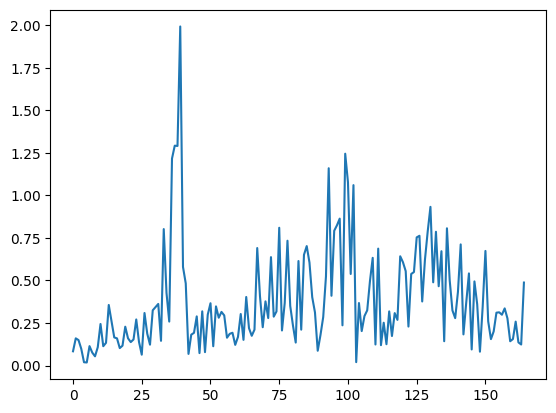

In [52]:
spectrum = df_test[
    (df_test["class"] == "crack")
    & (df_test["severity"] == "L")
    & (df_test["speed"] == 1000)
    & (df_test["load"] == 11)
    & (df_test["OT_method"] == "signal")
    & (df_test["installation"] == 1)
].iloc[0]["acc2"]
plt.plot(spectrum)

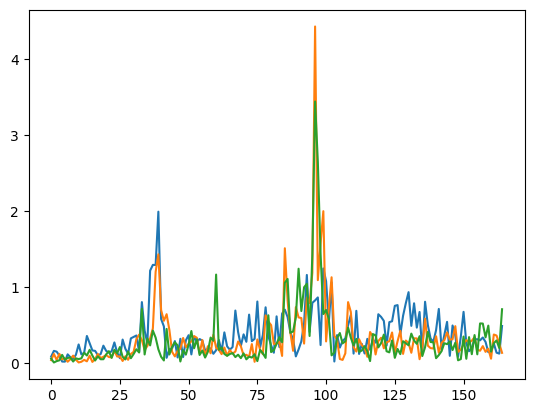

In [60]:
spectrum_healthy = df_test[
    (df_test["class"] == "healthy")
    & (df_test["speed"] == 1000)
    & (df_test["load"] == 11)
    & (df_test["OT_method"] == "signal")
    & (df_test["healthy_GP"] == 5)
].iloc[0]["acc2"]
plt.plot(spectrum)

spectrum_healthy2 = df_test[
    (df_test["class"] == "healthy")
    & (df_test["speed"] == 1000)
    & (df_test["load"] == 11)
    & (df_test["OT_method"] == "signal")
    & (df_test["healthy_GP"] == 6)
].iloc[0]["acc2"]

plt.plot(spectrum_healthy)
plt.plot(spectrum_healthy2)

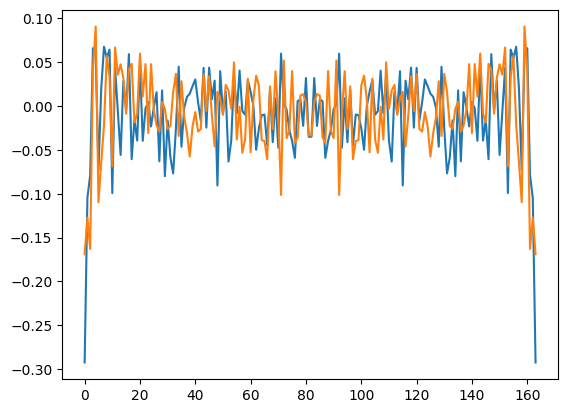

In [65]:
ceps_healthy = np.fft.ifft(np.log(spectrum_healthy)).real
ceps_healthy2 = np.fft.ifft(np.log(spectrum_healthy2)).real
ceps = np.fft.ifft(np.log(spectrum)).real
plt.plot(ceps_healthy[1:])
plt.plot(ceps[1:])

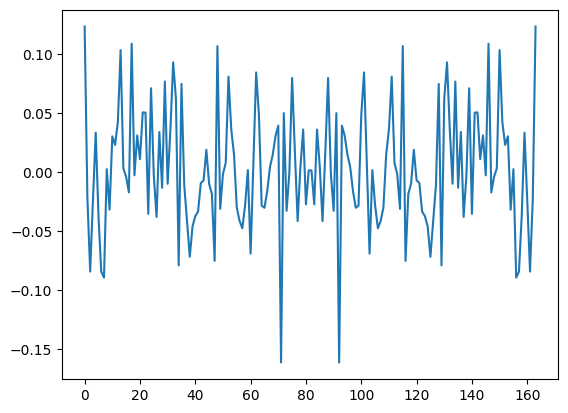

In [59]:
plt.plot(ceps[1:] - ceps_healthy[1:])

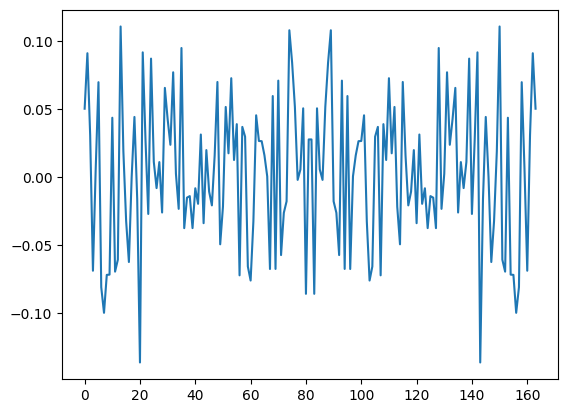

In [63]:
plt.plot(ceps_healthy2[1:] - ceps_healthy[1:])